In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import os




df = pd.read_csv(r"c:\Users\arjun\Desktop\Tech Layoff Analysis\dataset\tech_layoffs_2026_tracker.csv")
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


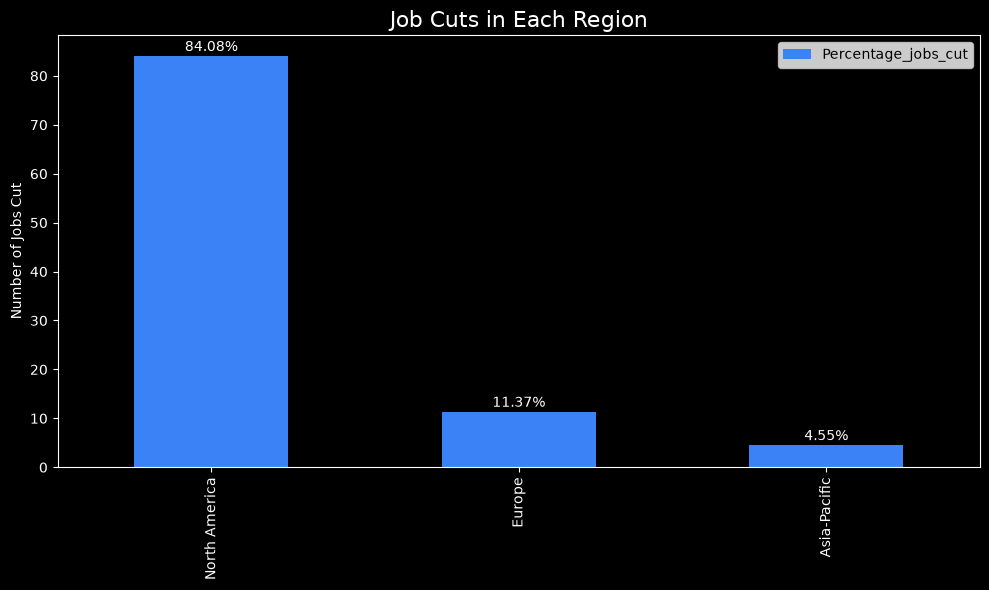

In [58]:
df_region = df.groupby(['region'])[['jobs_cut']].sum().sort_values('jobs_cut',ascending=False)
df_region['total_jobs_cut'] = df_region['jobs_cut'].sum()
df_region['Percentage_jobs_cut']  = (df_region['jobs_cut']/df_region['total_jobs_cut']*100).round(2)
df_region.drop('total_jobs_cut',axis=1,inplace=True)
df_region

fig, ax = plt.subplots(figsize=(10, 6))

# Background
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Bars
df_region.plot(
    kind='bar',
    y='Percentage_jobs_cut',
    ax=ax,
    color='#3B82F6'
)

# Titles & labels
ax.set_title('Job Cuts in Each Region', color='white', fontsize=16)
ax.set_ylabel('Number of Jobs Cut', color='white')
ax.set_xlabel('', color='white')

# Tick labels
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')


# Bar Labels
for i,j in enumerate(df_region.index):
    plt.text(i,df_region['Percentage_jobs_cut'].iloc[i]+1,f"{df_region['Percentage_jobs_cut'].iloc[i]}%", color = 'white', ha='center')

# Spines
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()

This clearly shows that North America is the largest region for job cuts, accounting for 84% of the total jobs cut.

In [59]:
df

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"
5,Salesforce,2026-01-10,1000,1.4,CRM/SaaS,USA,San Francisco,True,AI-driven efficiency and restructuring,37.9,...,1000,1000,NetworkWorld / Bloomberg,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.39,"March 18, 2026"
6,Autodesk,2026-01-25,1000,9.0,Design Software,USA,San Francisco,False,Post-Ansys acquisition restructuring,5.9,...,500,1200,NetworkWorld,January 2026,Q1 2026,North America,Medium (500-2K),Positive,9.09,"March 18, 2026"
7,eBay,2026-01-28,800,5.0,E-Commerce,USA,San Jose,True,AI-forward strategy in customer ops,10.3,...,1000,1000,NetworkWorld,January 2026,Q1 2026,North America,Medium (500-2K),Positive,7.27,"March 18, 2026"
8,Pinterest,2026-02-10,675,4.0,Social Media,USA,San Francisco,True,AI-forward content and marketing strategy,3.6,...,1500,200,NetworkWorld,February 2026,Q1 2026,North America,Medium (500-2K),Positive,18.24,"March 18, 2026"
9,Ericsson,2026-01-15,1600,12.0,Telecommunications,Sweden,Stockholm,False,Declining 5G demand and cost reduction,24.3,...,3000,5000,InformationWeek / FierceNetwork,January 2026,Q1 2026,Europe,Medium (500-2K),Positive,1.52,"March 18, 2026"


In [66]:
df[['company','jobs_cut','pre_layoff_headcount','pct_workforce_cut','laid_off_vs_headcount_pct']]

,company,jobs_cut,pre_layoff_headcount,pct_workforce_cut,laid_off_vs_headcount_pct
0,Amazon,16000,1550000,2.7,1.03
1,Block,4000,10000,40.0,40.00
2,Meta Reality Labs,1500,79000,10.0,1.90
3,Atlassian,1600,16000,10.0,10.00
4,Oracle,30000,200000,15.0,15.00
5,Salesforce,1000,72000,1.4,1.39
6,Autodesk,1000,11000,9.0,9.09
7,eBay,800,11000,5.0,7.27
8,Pinterest,675,3700,4.0,18.24
9,Ericsson,1600,105000,12.0,1.52


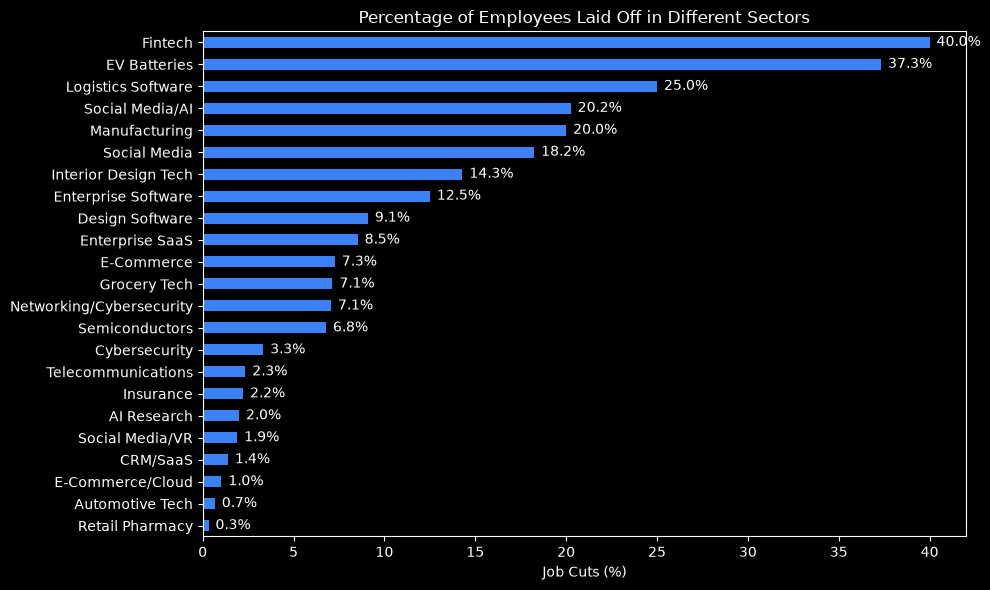

In [91]:
df_sector = df.groupby('sector')['laid_off_vs_headcount_pct'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('black')
ax.set_facecolor('black')

df_sector.plot(
    kind='barh',
    ax=ax,
    color='#3B82F6'
)

# Percentage values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        color='white',
        padding=5
    )

# Tick labels
ax.tick_params(axis='both', colors='white')

# Spines
for spine in ax.spines.values():
    spine.set_color('white')

# Labels
ax.set_title(
    'Percentage of Employees Laid Off in Different Sectors',
    color='white'
)

ax.set_ylabel('', color='white')
ax.set_xlabel('Job Cuts (%)', color='white')

plt.tight_layout()
plt.show()

Fintech has the highest workforce impact at 40%, followed by EV Batteries (37.3%) and Logistics Software (25%).

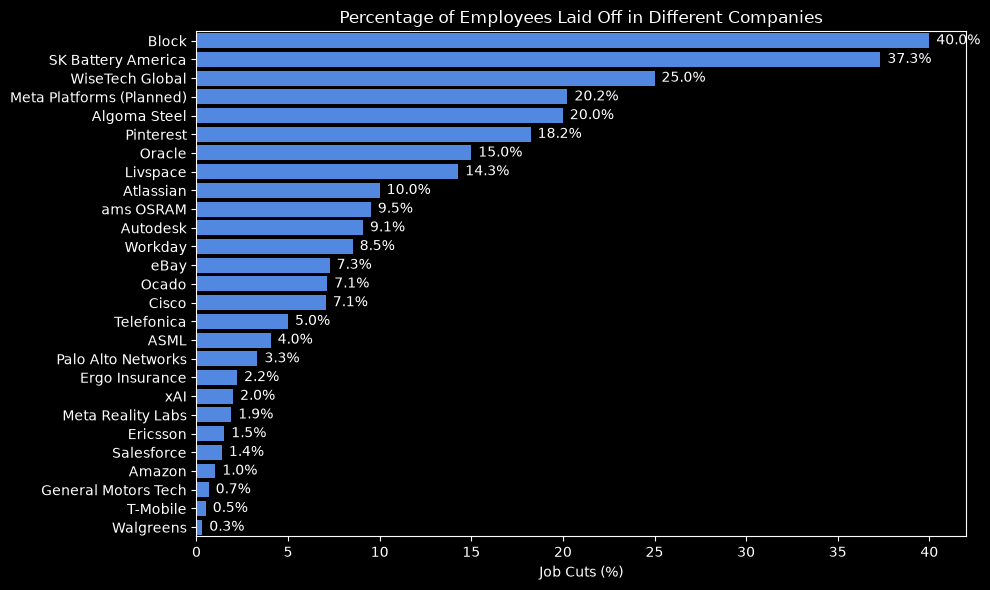

In [102]:
df_company = df[['company','laid_off_vs_headcount_pct']].sort_values('laid_off_vs_headcount_pct')

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('black')
ax.set_facecolor('black')

sns.barplot(
    data=df_company,
    x=df_company['laid_off_vs_headcount_pct'],
    y=df_company['company'],
    ax=ax,
    color='#3B82F6'
)

ax.invert_yaxis()

# Percentage values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        color='white',
        padding=5
    )

# Tick labels
ax.tick_params(axis='both', colors='white')

# Spines
for spine in ax.spines.values():
    spine.set_color('white')

# Labels
ax.set_title(
    'Percentage of Employees Laid Off in Different Companies',
    color='white'
)

ax.set_ylabel('', color='white')
ax.set_xlabel('Job Cuts (%)', color='white')

plt.tight_layout()
plt.show()